In [15]:
import pandas as pd
import numpy as np
import json
import torch
import matplotlib.pyplot as plt
from kan import KAN
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

TRAIN_DATA  = '../../data/processed/combined_hourly_train.csv'
TEST_DATA   = '../../data/processed/combined_hourly_test.csv'
SCALER_PATH = '../../data/processed/combined_hourly_scaler.json'

FEATURES     = ['temperature_c', 'precipitation_mm', 'solar_radiation_wm2',
                'windspeed_ms', 'humidity_pct', 'gas_price_mmbtu',
                'is_holiday', 'is_weekend',
                'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']
LAG_FEATURES = FEATURES + [f'load_lag{i}' for i in range(1, 25)]

TARGET = 'load_mw'

torch.manual_seed(1)

### 1. Load pre-engineered data

In [16]:
train = pd.read_csv(TRAIN_DATA, parse_dates=['datetime'], index_col='datetime')
test  = pd.read_csv(TEST_DATA,  parse_dates=['datetime'], index_col='datetime')

with open(SCALER_PATH) as f:
    scaler = json.load(f)
load_mean = scaler['load_mw']['mean']
load_std  = scaler['load_mw']['std']

print(f'Train: {len(train):,}  {train.index[0].date()} to {train.index[-1].date()}')
print(f'Test:  {len(test):,}   {test.index[0].date()} to {test.index[-1].date()}')
print(f'load_mw  mean={load_mean:.1f} MW  std={load_std:.1f} MW  (train only)')
print(f'{len(LAG_FEATURES)} input features')

Train: 42,076  2019-01-02 to 2023-10-20
Test:  10,519   2023-10-20 to 2024-12-31
load_mw  mean=25225.2 MW  std=4789.3 MW  (train only)
38 input features


### 2. Prepare tensors

In [17]:
def to_tensor(frame, cols):
    return torch.tensor(frame[cols].values, dtype=torch.float32)

dataset = {
    'train_input': to_tensor(train, LAG_FEATURES),
    'train_label': to_tensor(train, [TARGET]),
    'test_input':  to_tensor(test,  LAG_FEATURES),
    'test_label':  to_tensor(test,  [TARGET]),
}
print('train_input shape:', dataset['train_input'].shape)

train_input shape: torch.Size([42076, 38])


### 3. Build & train KAN

In [18]:
model = KAN(width=[len(LAG_FEATURES), 64, 1], grid=3, k=4, seed=42)

results1 = model.fit(
    dataset, opt='Adam', lr=1e-3,
    steps=1000, batch=2048,
    update_grid=True, lamb=0.0001, log=100,
)

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 6.45e-02 | test_loss: 1.05e-01 | reg: 1.06e+02 | : 100%|█| 1000/1000 [04:03<00:00,  4.

saving model version 0.1


### 4. Loss curve

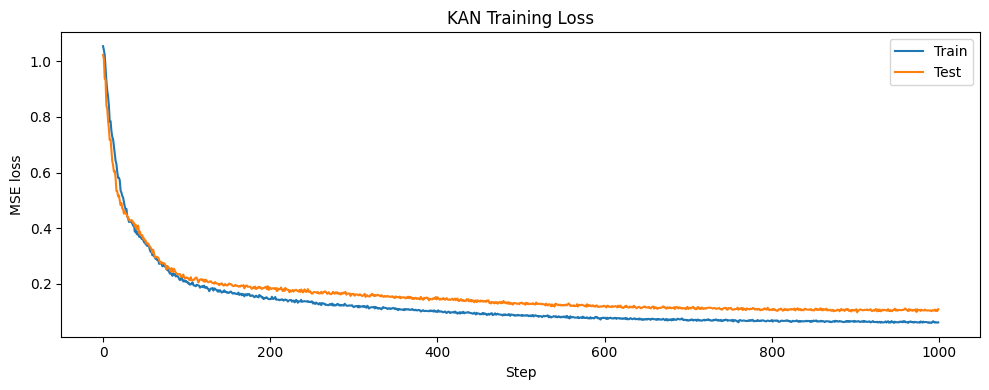

In [19]:
train_loss = results1['train_loss']
test_loss  = results1['test_loss']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_loss, label='Train')
ax.plot(test_loss,  label='Test')
ax.set_xlabel('Step')
ax.set_ylabel('MSE loss')
ax.set_title('KAN Training Loss')
ax.legend()
plt.tight_layout()
plt.show()

### 5. Evaluate on test set

In [20]:
model.eval()
with torch.no_grad():
    pred = model(dataset['test_input']).squeeze().numpy()

y_true = dataset['test_label'].squeeze().numpy()

rmse = np.sqrt(mean_squared_error(y_true, pred))
mae  = mean_absolute_error(y_true, pred)
r2   = r2_score(y_true, pred)

print(f'KAN (lag features, train-only scaler)')
print(f'  RMSE  {rmse:.4f}  ({rmse * load_std:.0f} MW)')
print(f'  MAE   {mae:.4f}  ({mae  * load_std:.0f} MW)')
print(f'  R2    {r2:.4f}')

KAN (lag features, train-only scaler)
  RMSE  0.1047  (502 MW)
  MAE   0.0777  (372 MW)
  R2    0.9884


### 6. Predictions vs actuals (first 2 weeks of test)

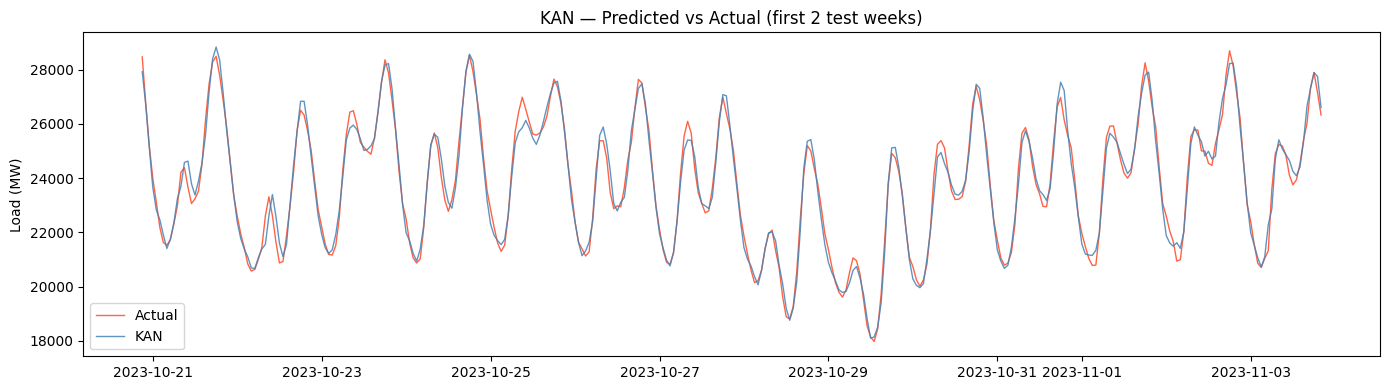

In [21]:
n      = 24 * 14
idx    = test.index[:n]
actual = y_true[:n] * load_std + load_mean

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(idx, actual,                          color='tomato',    linewidth=1,        label='Actual')
ax.plot(idx, pred[:n] * load_std + load_mean, color='steelblue', linewidth=1, alpha=0.85, label='KAN')
ax.set_ylabel('Load (MW)')
ax.set_title('KAN — Predicted vs Actual (first 2 test weeks)')
ax.legend()
plt.tight_layout()
plt.show()

### 7. KAN symbolic plot

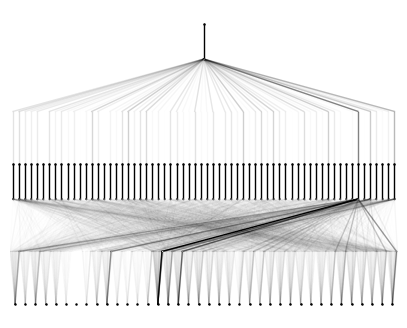

In [22]:
model.plot(beta=3)